# Data Understanding and Preparation 

Covers **Stage 1 (Dataset Understanding + EDA)** and **Stage 2 (Data Preparation)**. 
- Each stage below lists its **sub-tasks as a checklist**
- Complete every `# TODO` so each checklist item is satisfied
- Implement the reusable logic in `src/data_prep.py` and call it here so the same code backs your notebook and the later stages

**File ownership** — 
- *Provided (no change needed):* `config.py` (paths, target, column lists, params)
- *Provided to extend:* `src/data_prep.py` (function stubs)
- *You create:* the cells below + the report sections

**Business context:** flag diabetic inpatients at risk of 30-day readmission so care teams can intervene. The target is highly imbalanced (~9%), so metric choice and leakage prevention matter.

# Stage 1 - Business & Data Understanding, EDA, and Methodology

> **Stage 1 also has report-only tasks** graded from the MLOps report, not this notebook: **1.1 Business Understanding** (1.1.1–1.1.3) and **1.4 Methodology Design** (1.4.1–1.4.2).

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install sklearn

In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import src.data_prep as dp
import config as cfg

# load data/diabetic_data.csv treating '?' as NaN (na_values=['?']); print shape; head(3).
raw = dp.load_raw()
print(raw.shape)
raw.head(3)

icd9_grouping = pd.DataFrame({
    "diag_1": raw["diag_1"],
    "diag_2": raw["diag_2"],
    "diag_3": raw["diag_3"]
})

icd9_grouping


(101766, 50)


,diag_1,diag_2,diag_3
0,250.83,NaN,NaN
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
...,...,...,...
101761,250.13,291,458
101762,560,276,787
101763,38,590,296
101764,996,285,998


## Stage 1.2 — Dataset Understanding

- **1.2.1 — Dataset structure, target derivation & patients-vs-encounters [2]** — print the shape (~101,766 × 50), derive the target (`readmitted` `<30` → 1), and compare unique patients (`patient_nbr`) vs encounters.
- **1.2.2 — Feature types & data-quality / missing-value quantification [2]** — summarise feature types and build a per-column missing-value table with percentages (note `?` was loaded as NaN; e.g. `weight` ~97% missing).

In [ ]:
# 1.2.1: print rows/columns; compare unique patients vs encounters; derive the binary target.
# 1.2.2: print feature dtypes summary and a missing-value table (count + pct) per column.
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

# Compare unique patients vs encounters
num_encounters = len(raw)
num_patients = raw['patient_nbr'].nunique()
print(f"Encounters: {num_encounters:,}")
print(f"Unique patients: {num_patients:,}")
print(f"Encounters per patient (avg): {num_encounters / num_patients:.2f}")

# Readmitted patients within 30 days
readmitted = (raw['readmitted'] == '<30').astype(int)
print(f"\nReadmitted Patients (<30 days): {readmitted.mean():.2%} positive " 
      f"({readmitted.sum():,} of {len(readmitted):,})")

# Feature types
print("\nDtype counts:")
print(raw.dtypes.value_counts())

# missing-value table (count + pct) per columns
missing = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2),
}).sort_values("missing_pct", ascending=False)

print("\nColumns with missing values:")
missing[missing["missing_count"] > 0]


Shape: 101,766 rows x 50 columns
Encounters: 101,766
Unique patients: 71,518
Encounters per patient (avg): 1.42

Readmitted Patients (<30 days): 11.16% positive (11,357 of 101,766)

Dtype counts:
object    37
int64     13
Name: count, dtype: int64

Columns with missing values:


,missing_count,missing_pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


## Stage 1.3 — Exploratory Data Analysis

- **1.3.1 — Univariate analysis [3]** — visualise the target imbalance and ≥3 numeric feature distributions, with brief observations.
- **1.3.2 — Bivariate analysis vs target [2]** — analyse ≥1 relationship to the target (e.g. readmission rate vs prior inpatient visits) and interpret it.
- **1.3.3 — Visualisations + written interpretation [2]** — clear, labelled plots; interpret each key finding in writing (see the interpretation cell below).

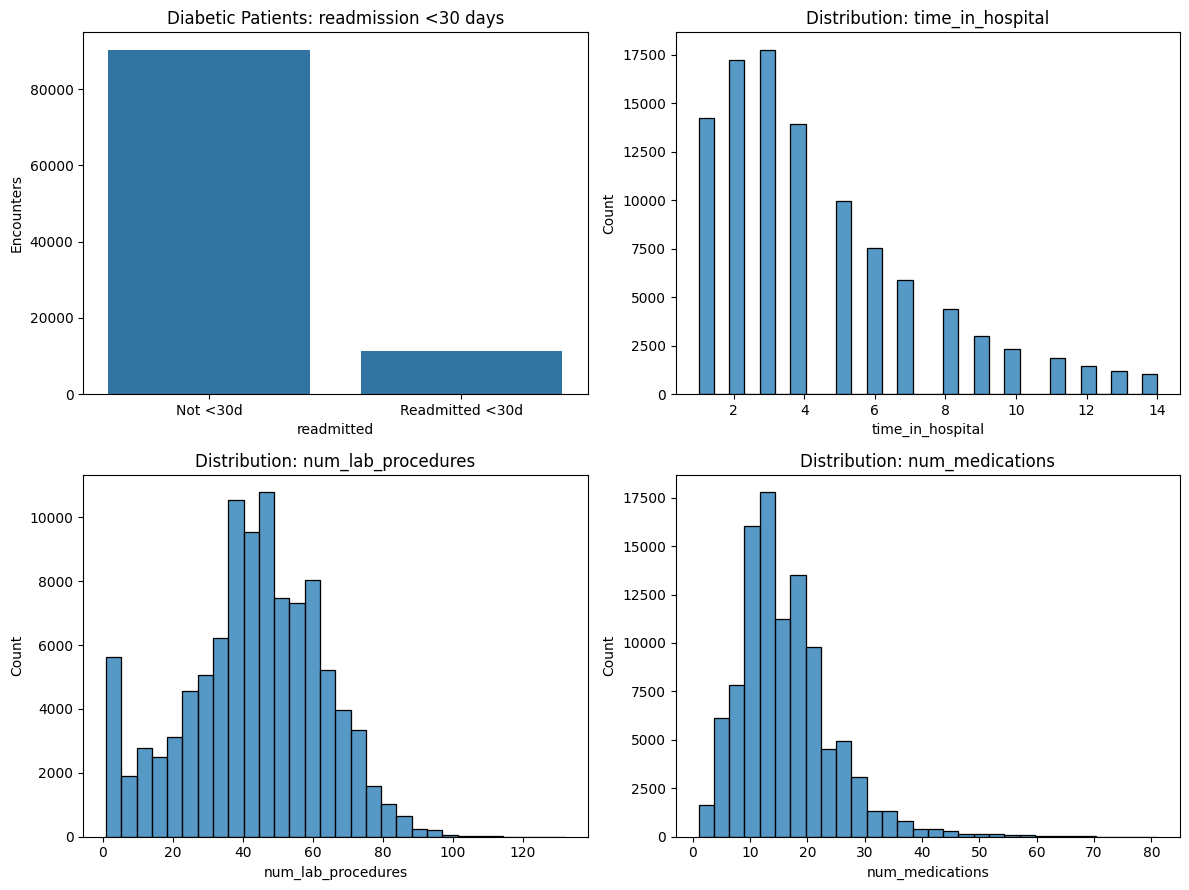

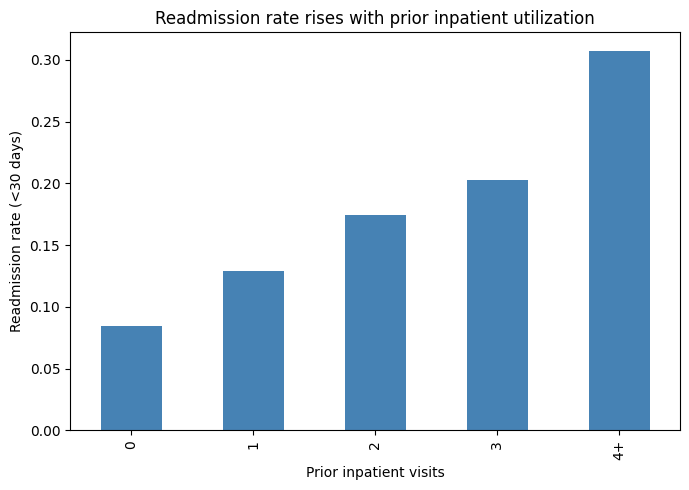

In [ ]:
# 1.3.1: plot the target imbalance + >=3 numeric distributions.
target_labels = (raw["readmitted"] == "<30").map({True: "Readmitted <30d", False: "Not <30d"})
numeric_feats = ["time_in_hospital", "num_lab_procedures", "num_medications", "number_diagnoses"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.countplot(x=target_labels, ax=axes[0, 0])
axes[0, 0].set_title("Diabetic Patients: readmission <30 days")
axes[0, 0].set_ylabel("Encounters")

for ax, col in zip(axes.flat[1:], numeric_feats):
    sns.histplot(raw[col], bins=30, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

# 1.3.2: plot >=1 bivariate view vs the target (e.g. readmit rate by prior inpatient visits).
bivar = raw.assign(target=(raw["readmitted"] == "<30").astype(int))
bivar["prior_inpatient_visits"] = bivar["number_inpatient"].clip(upper=4)
readmit_by_inpatient = bivar.groupby("prior_inpatient_visits")["target"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
readmit_by_inpatient.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xticklabels(["0", "1", "2", "3", "4+"])
ax.set_xlabel("Prior inpatient visits")
ax.set_ylabel("Readmission rate (<30 days)")
ax.set_title("Readmission rate rises with prior inpatient utilization")
plt.tight_layout()
plt.show()

# 1.3.3: ensure plots are labelled; record findings in the interpretation cell.


### ✍️ Interpretation (1.3.3)
*TODO: what does the ~9% imbalance imply for metric choice? Which columns are unusable (e.g. weight ~97% missing) and why? What does the bivariate view tell you?*

## Stage 2 — Data Preparation  

## Stage 2.1 — Data Cleaning 

Implement `clean()` in `src/data_prep.py`, then call it here.

- **2.1.1 — Missing value handling & invalid value treatment [2]** — `?`→NaN; drop `weight` and constant/zero-variance medication columns.
- **2.1.2 — Patient deduplication & removal of invalid records [2]** — keep the FIRST encounter per patient (`drop_duplicates('patient_nbr')`, prevents leakage); drop expired/hospice discharges (`discharge_disposition_id` ∈ {11,13,14,19,20,21}).
- **2.1.3 — Target variable creation & validation [2]** — build the binary target and validate its class balance (expect ~69,973 rows, ~9% positive).

In [ ]:
# (src/data_prep.py clean()): implement sub-tasks 2.1.1–2.1.3 above.
# (here): clean = dp.clean(raw); print the resulting shape and target rate.

clean = dp.clean(raw)

print(f"Raw: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Cleaned: {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Removed: {len(raw) - len(clean):,} rows " 
      f"(duplicate patients + expired/hospice discharges)")

# Target variable creation & validation
counts = clean[cfg.TARGET].value_counts()
print(f"\nTarget '{cfg.TARGET}' balance:")
print(f"  0 (not readmitted <30d): {counts[0]:,}")
print(f"  1 (readmitted <30d):     {counts[1]:,}")
print(f"  Positive rate: {clean[cfg.TARGET].mean():.2%}  -> imbalanced")

# Confirm the dropped columns are gone
print(f"\nDropped columns still present: "
      f"{[col for col in cfg.DROP_COLS if col in clean.columns]}")
print(f"Remaining NaNs:\n{clean.isna().sum()[lambda s: s > 0]}")


Raw: 101,766 rows x 50 columns
Cleaned: 69,973 rows x 38 columns
Removed: 31,793 rows (duplicate patients + expired/hospice discharges)

Target 'readmitted_30d' balance:
  0 (not readmitted <30d): 63,696
  1 (readmitted <30d):     6,277
  Positive rate: 8.97%  -> imbalanced

Dropped columns still present: []
Remaining NaNs:
race                  1918
medical_specialty    33639
diag_1                  10
diag_2                 293
diag_3                1224
max_glu_serum        66625
A1Cresult            57128
dtype: int64


## Stage 2.2 — Feature Engineering 

Implement `engineer_features()` in `src/data_prep.py`.

- **2.2.1 — ICD-9 diagnosis grouping into clinical categories [4]** — group `diag_1/2/3` into clinical categories (circulatory, respiratory, diabetes, injury, other) with a justified mapping.
- **2.2.2 — Additional engineered features, justified [4]** — ≥3 of {age midpoint, service_utilization, num_med_changes, medical_specialty top-k grouping}, each justified.

In [ ]:
# (src/data_prep.py engineer_features()): implement sub-tasks 2.2.1–2.2.2 above.
# (here): fe = dp.engineer_features(clean); preview the new feature columns.
fe = dp.engineer_features(clean)
print(f"Engineered frame: {fe.shape[0]:,} rows x {fe.shape[1]} columns")

new_cols = ["diag_1_category", "diag_2_category", "diag_3_category",
            "age_midpoint", "service_utilization", "num_med_changes",
            "medical_specialty"]
display(fe[new_cols].head(10))

# ICD-9 grouping: 700+ raw codes -> 9 clinical categories
print("\nPrimary Diagnosis (diag_1) categories:")
print(fe["diag_1_category"].value_counts())

# sanity-check each engineered feature
print("\nage_midpoint:", sorted(fe["age_midpoint"].unique()))
print("service_utilization:", fe["service_utilization"].describe()[["mean", "max"]].to_dict())
print("num_med_changes:", fe["num_med_changes"].value_counts().sort_index().to_dict())
print(f"medical_specialty: {fe['medical_specialty'].nunique()} levels (was 73)")

Engineered frame: 69,973 rows x 40 columns


,diag_1_category,diag_2_category,diag_3_category,age_midpoint,service_utilization,num_med_changes,medical_specialty
0,Circulatory,Circulatory,Other,85.0,0,0,Other
1,Circulatory,Neoplasms,Respiratory,95.0,0,0,InternalMedicine
2,Neoplasms,Neoplasms,Diabetes,45.0,0,0,Other
3,Diabetes,Circulatory,Injury,45.0,0,0,Other
4,Circulatory,Circulatory,Diabetes,55.0,0,0,Other
5,Neoplasms,Other,Neoplasms,65.0,0,1,Other
6,Circulatory,Diabetes,Diabetes,45.0,1,2,Family/GeneralPractice
7,Circulatory,Circulatory,Circulatory,85.0,0,0,Family/GeneralPractice
8,Circulatory,Circulatory,Other,65.0,0,0,Other
9,Respiratory,Injury,Genitourinary,65.0,0,0,Other



Primary Diagnosis (diag_1) categories:
diag_1_category
Circulatory        21384
Other              12122
Respiratory         9486
Digestive           6487
Diabetes            5748
Injury              4694
Musculoskeletal     4064
Genitourinary       3440
Neoplasms           2538
Missing               10
Name: count, dtype: int64

age_midpoint: [np.float64(5.0), np.float64(15.0), np.float64(25.0), np.float64(35.0), np.float64(45.0), np.float64(55.0), np.float64(65.0), np.float64(75.0), np.float64(85.0), np.float64(95.0)]
service_utilization: {'mean': 0.5597015991882583, 'max': 49.0}
num_med_changes: {0: 52725, 1: 16252, 2: 919, 3: 74, 4: 3}
medical_specialty: 11 levels (was 73)


2.2.1 diag_1/2/3 hold 700+ raw ICD-9 codes; used directly they'd one-hot into thousands of sparse columns. Grouping by the standard ICD-9 chapter ranges (250.xx → Diabetes, 390–459 → Circulatory, 460–519 → Respiratory, 800–999 → Injury, …) keeps the clinical signal at ~9 levels. V/E codes are supplementary, not diagnoses, so they fall to Other.

2.2.2

age_midpoint — age is an ordered band string ([70-80)); the midpoint makes that order usable by the model, where one-hot would throw it away.
service_utilization — prior outpatient + emergency + inpatient visits. EDA (1.3.2) showed readmission rate climbs steeply with prior inpatient visits; the sum is a single strong "frequent flyer" signal.
num_med_changes — count of Up/Down across the 15 medication columns. Active regimen adjustment is a proxy for an unstable, harder-to-control patient.
medical_specialty — 73 levels with a long tail and ~49% missing. Top-10 + Other prevents rare levels that appear in train but not test.

## Stage 2.3 — Feature Transformation

Implement `build_preprocessor()` in `src/data_prep.py`.

- **2.3.1 — Numeric scaling & categorical encoding [3]** — numeric: median-impute + scale; categorical: impute + `OneHotEncoder(handle_unknown='ignore')`.
- **2.3.2 — Leakage-safe ColumnTransformer/Pipeline assembly [2]** — assemble ONE ColumnTransformer; do **not** fit it yet (fitting happens on the train split only, in 2.4).

In [ ]:
# (src/data_prep.py build_preprocessor()): implement sub-tasks 2.3.1–2.3.2 above.

numeric, categorical = dp.get_feature_lists(fe)
print(f"Numeric ({len(numeric)}): {numeric}")
print(f"\nCategorical ({len(categorical)}): {categorical}")
print("\nNote: admission_type_id / discharge_disposition_id / admission_source_id "
      "are int-coded lookups -> treated as CATEGORICAL, not numeric.")

# construct the (unfitted) preprocessor and show its structure.
preprocessor = dp.build_preprocessor(numeric, categorical)
print(f"\nFitted? {hasattr(preprocessor, 'transformers_')} <- must be False here")
preprocessor # renders the HTML diagram


Numeric (11): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint', 'service_utilization', 'num_med_changes']

Categorical (28): ['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category']

Note: admission_type_id / discharge_disposition_id / admission_source_id are int-coded lookups -> treated as CATEGORICAL, not numeric.

Fitted? False <- must be False here


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_outpatient', 'number_emergency',
                                  'number_inpatient', 'number_diagnoses',
                                  'age_midpoint', 'service_utilization',
                                  'num_med_changes']),
                                ('cat',
                                 Pipel...
                                  'admission_source_id', 'medical_specialty',
                                  'max_glu_serum', 'A1Cresult', 'metformin',
                                  'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride', 'glipizide',
                                  'glyburide', 'pioglitazone', 'rosiglitazone',
                                  'acarbose', 'miglitol', 'tolazamide',
                                  'insulin', 'glyburide-metformin',
                                  'glipizide-metformin', 'change',
                                  'diabetesMed', 'diag_1_category',
                                  'diag_2_category', 'diag_3_category'])])

## Stage 2.4 — Validation & Splitting

Implement `get_splits()` in `src/data_prep.py`.

- **2.4.1 — Stratified train/validation/test split created first [3]** — STRATIFIED split BEFORE any fitting (`random_state=42`; class ratio preserved).
- **2.4.2 — Leakage-safe fit-on-train + class-balance check [3]** — fit the preprocessor on TRAIN only, transform val/test; confirm the class ratio is preserved across splits.

In [ ]:
# (src/data_prep.py get_splits()): implement sub-tasks 2.4.1–2.4.2 above.
# (here): create splits; fit preprocessor on train only; print split sizes,
#       feature count, and the class ratio per split (confirm no leakage).
X_train, X_val, X_test, y_train, y_val, y_test = dp.get_splits(fe)

print("Split sizes:")
for name, y_ in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name:5s}: {len(y_):>6,} rows ({len(y_)/len(fe):5.1%})  "
          f"positive rate {y_.mean():.2%}")
print(f"  Full frame positive rate: {fe[cfg.TARGET].mean():.2%} <- ratio preserved")

# fit on TRAIN ONLY, then transform val/test
preprocessor.fit(X_train)       # learns medians/categories from train
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val) # transform only - no refit
X_test_t  = preprocessor.transform(X_test)

print(f"\nAfter transform: {X_train.shape[1]} raw features -> "
      f"{X_train_t.shape[1]} encoded features")
for name, arr in [("train", X_train_t), ("val", X_val_t), ("test", X_test_t)]:
    print(f"  {name:5s}: {arr.shape}")

print("\nLeakage check:")
print(f"  Preprocessor fit on {len(X_train):,} train rows only "
      f"(not the {len(fe):,}-row full frame)")
print(f"  Row overlap train/test: "
      f"{len(set(X_train.index) & set(X_test.index))} <- must be 0")


Split sizes:
  train: 44,782 rows (64.0%)  positive rate 8.97%
  val  : 11,196 rows (16.0%)  positive rate 8.97%
  test : 13,995 rows (20.0%)  positive rate 8.97%
  Full frame positive rate: 8.97% <- ratio preserved

After transform: 39 raw features -> 172 encoded features
  train: (44782, 172)
  val  : (11196, 172)
  test : (13995, 172)

Leakage check:
  Preprocessor fit on 44,782 train rows only (not the 69,973-row full frame)
  Row overlap train/test: 0 <- must be 0
